## Triplet Mining

In [48]:
from shapely.geometry import Point
from shapely import STRtree
import json
import polars as pl
from staticmap3 import CircleMarker, StaticMap

In [2]:
with open("../dataset/sea-mapqa/pois.json", "r") as f:
    data = json.loads(f.read())

In [31]:
df = pl.DataFrame(data).with_row_index("row_idx")
df_id = df.filter((pl.col("country") == "Indonesia") & (pl.col("name") != "")).sample(
    100
)
df_id.write_json("../dataset/sea-mapqa/anchor-id.json")

In [29]:
# build tree index based on all pois
points = [Point(d["lon"], d["lat"]) for d in df.to_dicts()]
tree = STRtree(points)

In [43]:
# iterate query over anchor pois
radius_meters = 1000
radius_deg = radius_meters / 111_000
for d in df_id.to_dicts():
    anchor = Point(d["lon"], d["lat"])
    buffer = anchor.buffer(radius_deg)
    candidates = tree.query(buffer)
    break

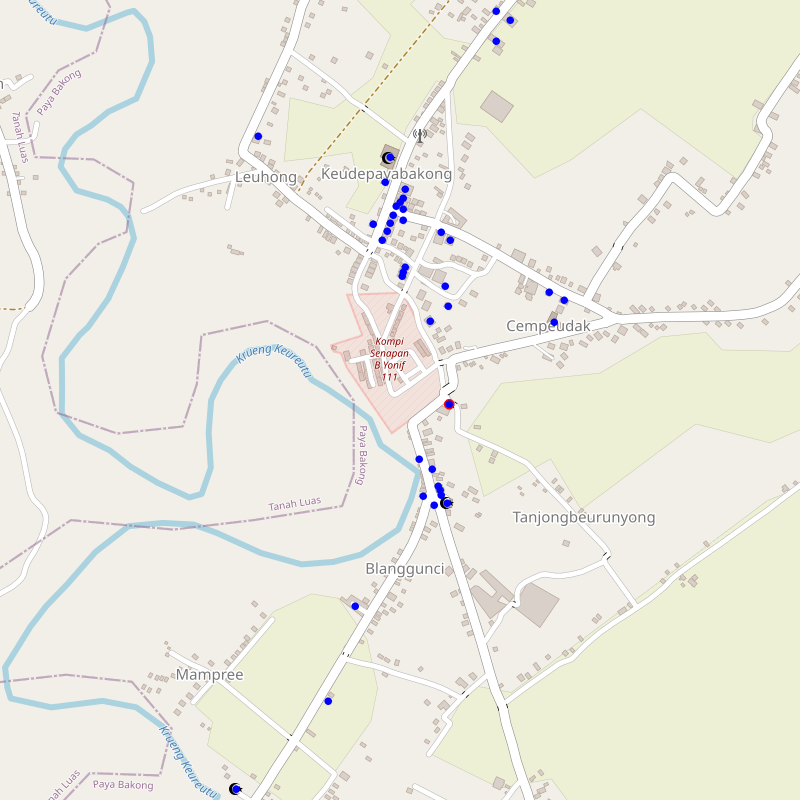

In [52]:
# validate poi points
m = StaticMap(800, 800)

m.add_marker(CircleMarker((d["lon"], d["lat"]), color="red", width=10))
for c in candidates:
    dd = data[c]
    m.add_marker(CircleMarker((dd["lon"], dd["lat"]), color="blue", width=7))

image = m.render(zoom=16)
image

In [56]:
[data[c] for c in candidates]

[{'osm_id': 1190818071,
  'lat': 4.98134635,
  'lon': 97.22572645,
  'poi_class': 'amenity',
  'poi_type': 'place_of_worship',
  'name': "Mesjid Baitul Sa'adah Mtg Payang",
  'city': 'Aceh Utara',
  'country': 'Indonesia',
  'country_code': 'ID',
  'bounding_box': [4.9812552, 97.2256351, 4.9814375, 97.2258178],
  'extra_tags': {'amenity': 'place_of_worship',
   'building': 'yes',
   'name': "Mesjid Baitul Sa'adah Mtg Payang",
   'religion': 'muslim'}},
 {'osm_id': 1190818058,
  'lat': 4.9832418999999994,
  'lon': 97.22770034999999,
  'poi_class': 'shop',
  'poi_type': 'coffee',
  'name': 'seramou kupi',
  'city': 'Aceh Utara',
  'country': 'Indonesia',
  'country_code': 'ID',
  'bounding_box': [4.9831806, 97.2276318, 4.9833032, 97.2277689],
  'extra_tags': {'addr:place': 'seramou kupi',
   'building': 'yes',
   'name': 'seramou kupi',
   'shop': 'coffee'}},
 {'osm_id': 1190818042,
  'lat': 4.98526835,
  'lon': 97.22827015,
  'poi_class': 'amenity',
  'poi_type': 'school',
  'name': 'Da